In [2]:
import tskit
import msprime
import demes
import demesdraw

<Axes: ylabel='time ago (generations)'>

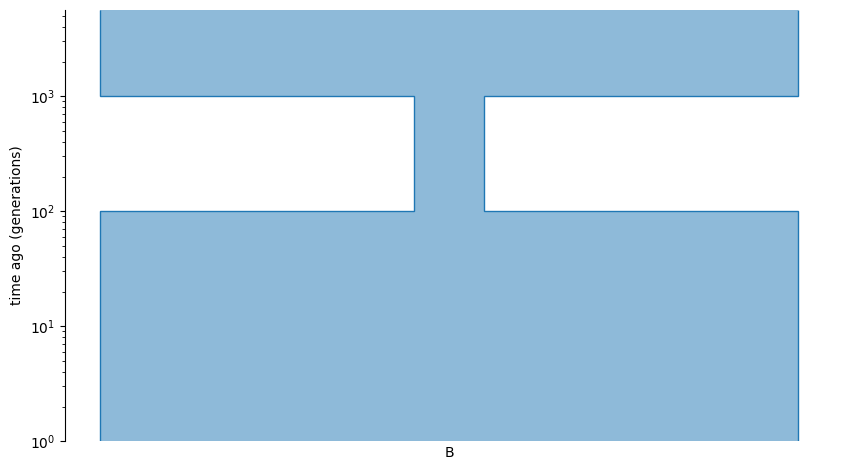

In [16]:

graph = demes.load("snakemake/graph.yml")
demography = msprime.Demography.from_demes(graph)
demesdraw.tubes(graph, log_time=True)

for seed in range(1, 51):
    demography = msprime.Demography.from_demes(graph)
    ts = msprime.sim_ancestry(20, random_seed=seed, ploidy=1, sequence_length=10000, recombination_rate=0.00001, demography=demography)
    ts = msprime.sim_mutations(ts, rate=0.00001, random_seed=seed)

    sfs = ts.allele_frequency_spectrum(polarised=True, span_normalise=False)[1:-1]
    print("SFS:", sfs)

    #export array to sfs_new.blk separated by spaces
    with open(f"sfss/sfs_{seed}.blk", "w") as f:
        for value in sfs:
            f.write(f"{value} ")
        f.write("\n")


<Axes: xlabel='time ago (generations)', ylabel='deme\nsize'>

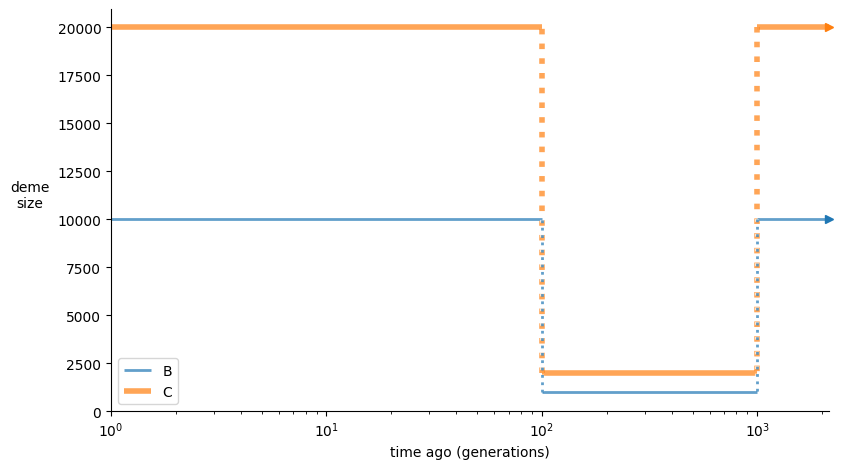

In [18]:
graph = demes.load("graph.yml")
demesdraw.size_history(graph, log_time=True)